# Chicago 311: Do Wealthier Neighborhoods Get Faster City Services?

**An equity analysis of 2.5 million Chicago 311 service requests (Sep 2023 – Sep 2026)**

Chicago receives millions of 311 service requests each year — potholes, streetlights, rodent complaints, graffiti, and more. This analysis investigates whether response times and service quality vary systematically by neighborhood income level.

**Research Question:** Do wealthier Chicago neighborhoods receive faster 311 service responses than lower-income neighborhoods?

**Approach:**
1. Pull 3 years of completed 311 requests with location data (2.5M records)
2. Join with Census socioeconomic data by community area
3. Compare response times across income quartiles
4. Use NLP to understand what different neighborhoods report
5. Test significance with statistical methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.options.display.float_format = '{:.2f}'.format

DATA_DIR = Path("../data")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/pkeel

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/pkeel/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.start()
  File "/home/pkeel

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.5.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load Data

We use two datasets:
- **311 Service Requests** — completed requests from 2023–2026 with location, timestamps, and service type (via Chicago Data Portal)
- **Community Area Socioeconomic Indicators** — per-capita income, poverty rate, and hardship index for Chicago's 77 community areas (Census ACS via Chicago Data Portal)

In [2]:
# Load 311 service requests
df = pd.read_parquet(DATA_DIR / "chicago_311.parquet")
print(f"311 requests: {len(df):,} rows")
print(f"Date range: {df['created_date'].min():%Y-%m-%d} to {df['created_date'].max():%Y-%m-%d}")
print(f"Service types: {df['sr_type'].nunique()}")
print(f"Community areas: {df['community_area'].dropna().nunique()}")
print(f"Duplicates flagged: {df['duplicate'].sum():,} ({df['duplicate'].mean():.1%})")

# Remove duplicate requests — keeps the original, avoids double-counting
df = df[~df["duplicate"]].copy()
print(f"\nAfter removing duplicates: {len(df):,} rows")
df.head(3)

311 requests: 2,523,373 rows
Date range: 2023-09-01 to 2026-09-21
Service types: 105
Community areas: 77
Duplicates flagged: 206,103 (8.2%)



After removing duplicates: 2,317,270 rows


,sr_number,sr_type,sr_short_code,owner_department,status,origin,created_date,closed_date,last_modified_date,street_address,community_area,ward,latitude,longitude,duplicate,created_hour,created_day_of_week,created_month,zip_code,response_hours
0,SR23-01485999,Graffiti Removal Request,GRAF,Streets and Sanitation,Completed,Internet,2023-09-01 00:03:45,2023-09-01 09:29:45,2023-09-01 09:29:45,4359 S KEATING AVE,56.00,22.00,41.81,-87.74,False,0,6,9,60632.00,9.43
1,SR23-01486000,Vicious Animal Complaint,EAF,Animal Care and Control,Completed,Phone Call,2023-09-01 00:04:13,2023-09-01 17:08:28,2023-09-01 17:08:28,7605 S LUELLA AVE,43.00,7.00,41.76,-87.57,False,0,6,9,60649.00,17.07
2,SR23-01486001,Graffiti Removal Request,GRAF,Streets and Sanitation,Completed,Internet,2023-09-01 00:05:58,2023-09-01 08:03:19,2023-09-01 08:03:19,4704 S KARLOV AVE,57.00,14.00,41.81,-87.73,False,0,6,9,60632.00,7.96


In [3]:
# Load community area socioeconomic data
socio = pd.read_parquet(DATA_DIR / "community_area_socioeconomic.parquet")
print(f"Raw rows: {len(socio)}")
print(f"Columns: {socio.columns.tolist()}")
print()

# All columns are strings — convert numeric fields
socio["ca"] = pd.to_numeric(socio["ca"], errors="coerce")
socio["per_capita_income_"] = pd.to_numeric(socio["per_capita_income_"], errors="coerce")
socio["hardship_index"] = pd.to_numeric(socio["hardship_index"], errors="coerce")
socio["percent_households_below_poverty"] = pd.to_numeric(socio["percent_households_below_poverty"], errors="coerce")

# Drop the citywide total row (ca=NaN or 0)
socio = socio[socio["ca"].between(1, 77)].copy()
print(f"Community areas after cleanup: {len(socio)}")
print(f"Income range: ${socio['per_capita_income_'].min():,.0f} to ${socio['per_capita_income_'].max():,.0f}")
print(f"Hardship range: {socio['hardship_index'].min():.0f} to {socio['hardship_index'].max():.0f}")
socio[["ca", "community_area_name", "per_capita_income_", "hardship_index", "percent_households_below_poverty"]].head()

Raw rows: 78
Columns: ['ca', 'community_area_name', 'percent_of_housing_crowded', 'percent_households_below_poverty', 'percent_aged_16_unemployed', 'percent_aged_25_without_high_school_diploma', 'percent_aged_under_18_or_over_64', 'per_capita_income_', 'hardship_index']

Community areas after cleanup: 77
Income range: $8,201 to $88,669
Hardship range: 1 to 98


,ca,community_area_name,per_capita_income_,hardship_index,percent_households_below_poverty
0,1.00,Rogers Park,23939,39.00,23.60
1,2.00,West Ridge,23040,46.00,17.20
2,3.00,Uptown,35787,20.00,24.00
3,4.00,Lincoln Square,37524,17.00,10.90
4,5.00,North Center,57123,6.00,7.50


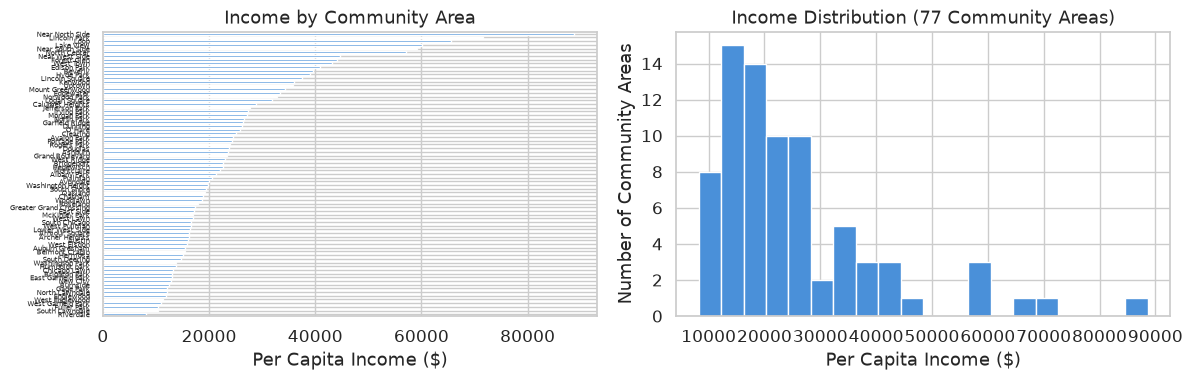

In [4]:
# Preview income distribution across community areas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

socio.sort_values("per_capita_income_").plot.barh(
    x="community_area_name", y="per_capita_income_", ax=axes[0],
    color="#4a90d9", legend=False
)
axes[0].set_xlabel("Per Capita Income ($)")
axes[0].set_ylabel("")
axes[0].set_title("Income by Community Area")
axes[0].tick_params(axis="y", labelsize=5)

socio["per_capita_income_"].hist(bins=20, ax=axes[1], color="#4a90d9", edgecolor="white")
axes[1].set_xlabel("Per Capita Income ($)")
axes[1].set_ylabel("Number of Community Areas")
axes[1].set_title("Income Distribution (77 Community Areas)")
plt.tight_layout()
plt.savefig(FIG_DIR / "income_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Richest and poorest community areas for context
print("Top 5 highest income:")
for _, r in socio.nlargest(5, "per_capita_income_").iterrows():
    print(f"  {r['community_area_name']:<25} ${r['per_capita_income_']:>8,.0f}  (hardship: {r['hardship_index']:.0f})")

print("\nTop 5 lowest income:")
for _, r in socio.nsmallest(5, "per_capita_income_").iterrows():
    print(f"  {r['community_area_name']:<25} ${r['per_capita_income_']:>8,.0f}  (hardship: {r['hardship_index']:.0f})")

Top 5 highest income:
  Near North Side           $  88,669  (hardship: 1)
  Lincoln Park              $  71,551  (hardship: 2)
  Loop                      $  65,526  (hardship: 3)
  Lake View                 $  60,058  (hardship: 5)
  Near South Side           $  59,077  (hardship: 7)

Top 5 lowest income:
  Riverdale                 $   8,201  (hardship: 98)
  South Lawndale            $  10,402  (hardship: 96)
  Fuller Park               $  10,432  (hardship: 97)
  West Garfield Park        $  10,934  (hardship: 92)
  West Englewood            $  11,317  (hardship: 89)


## 2. Exploratory Data Analysis

Before testing our equity hypothesis, let's understand the shape of the data — what types of requests are most common, how response times are distributed, and how requests vary across the city.

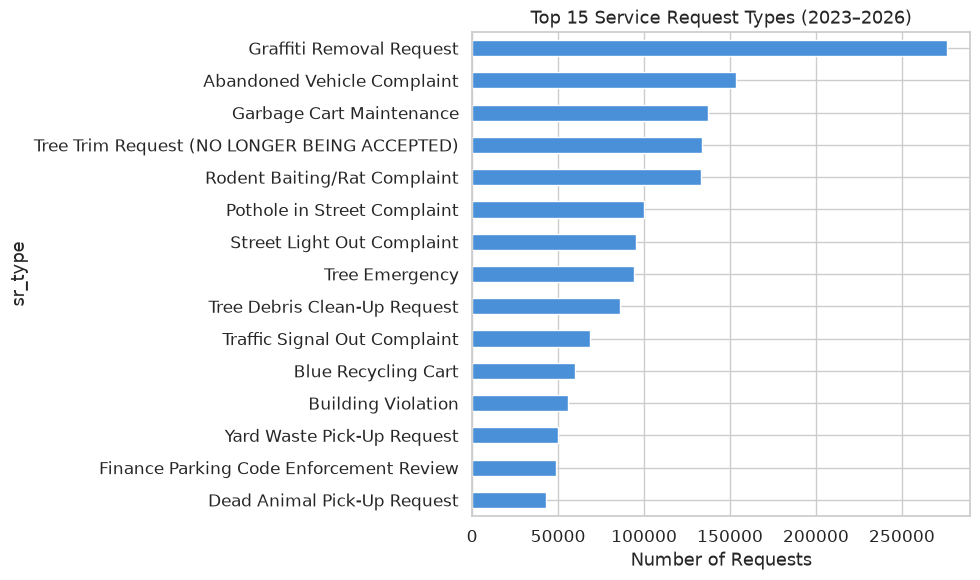

In [6]:
# Top 15 service request types
top_types = df["sr_type"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_types.plot.barh(ax=ax, color="#4a90d9", edgecolor="white")
ax.set_xlabel("Number of Requests")
ax.set_title("Top 15 Service Request Types (2023–2026)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "top_request_types.png", dpi=150, bbox_inches="tight")
plt.show()

Median response time: 2.6 days
Mean response time: 24.2 days
90th percentile: 49.2 days
Requests resolved same day: 37.5%


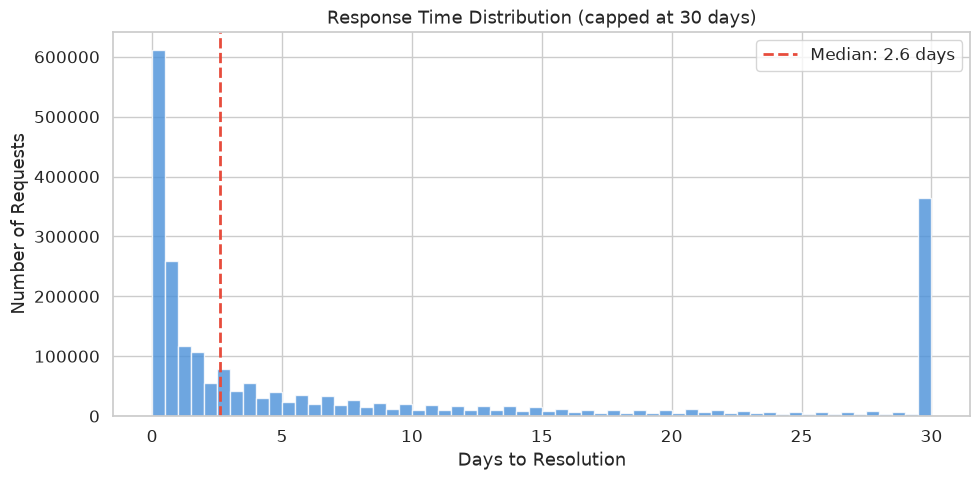

In [7]:
# Response time distribution (cap at 30 days for visualization)
response_days = df["response_hours"] / 24
print(f"Median response time: {response_days.median():.1f} days")
print(f"Mean response time: {response_days.mean():.1f} days")
print(f"90th percentile: {response_days.quantile(0.9):.1f} days")
print(f"Requests resolved same day: {(response_days < 1).mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
response_days.clip(upper=30).hist(bins=60, ax=ax, color="#4a90d9", edgecolor="white", alpha=0.8)
ax.set_xlabel("Days to Resolution")
ax.set_ylabel("Number of Requests")
ax.set_title("Response Time Distribution (capped at 30 days)")
ax.axvline(response_days.median(), color="#e74c3c", linestyle="--", linewidth=2, label=f"Median: {response_days.median():.1f} days")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "response_time_dist.png", dpi=150, bbox_inches="tight")
plt.show()

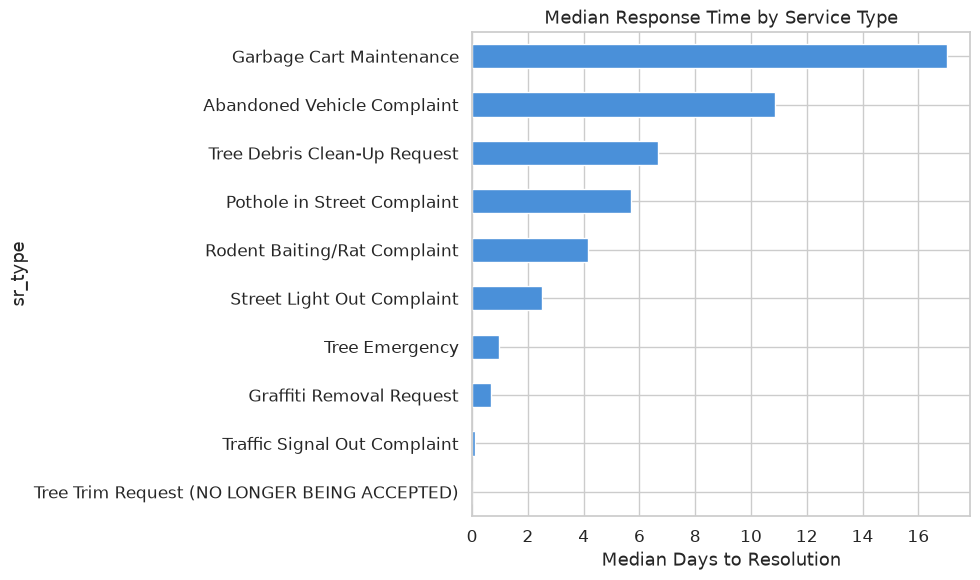

In [8]:
# Response time by request type (top 10)
top10 = df[df["sr_type"].isin(top_types.head(10).index)].copy()
top10["response_days"] = top10["response_hours"] / 24

medians = top10.groupby("sr_type")["response_days"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
medians.plot.barh(ax=ax, color="#4a90d9", edgecolor="white")
ax.set_xlabel("Median Days to Resolution")
ax.set_title("Median Response Time by Service Type")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "response_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Equity Analysis: Response Time by Income

This is the core question. We join 311 requests with community area income data, divide neighborhoods into income quartiles, and compare response times.

If the city delivers services equitably, we should see **no significant difference** in response times across income groups.

In [9]:
# Join 311 data with community area socioeconomic indicators
# 311 community_area is float64 (1.0-77.0), socio ca is int (1-77)
df["community_area"] = df["community_area"].astype("Int64")
socio["ca"] = socio["ca"].astype("Int64")

# Rename for merge
socio_merge = socio[["ca", "community_area_name", "per_capita_income_", "hardship_index",
                      "percent_households_below_poverty"]].rename(columns={
    "ca": "community_area",
    "per_capita_income_": "per_capita_income",
    "percent_households_below_poverty": "poverty_pct",
})

df = df.merge(socio_merge, on="community_area", how="left")

matched = df["per_capita_income"].notna().sum()
print(f"Matched {matched:,} / {len(df):,} requests ({matched/len(df):.1%}) with income data")
print(f"Unmatched (no community area): {df['per_capita_income'].isna().sum():,}")
print(f"\nIncome stats of matched requests:")
print(f"  Mean income: ${df['per_capita_income'].mean():,.0f}")
print(f"  Median income: ${df['per_capita_income'].median():,.0f}")

Matched 2,315,469 / 2,317,270 requests (99.9%) with income data
Unmatched (no community area): 1,801

Income stats of matched requests:
  Mean income: $27,283
  Median income: $22,677


In [10]:
# Create income quartiles
df_inc = df.dropna(subset=["per_capita_income", "response_hours"]).copy()
df_inc["response_days"] = df_inc["response_hours"] / 24

# Cap extreme outliers at 365 days (1 year) — anything beyond is likely a data issue
outlier_count = (df_inc["response_days"] > 365).sum()
print(f"Response times > 1 year: {outlier_count:,} ({outlier_count/len(df_inc):.2%}) — capping at 365")
df_inc["response_days"] = df_inc["response_days"].clip(upper=365)

# Assign quartile based on community area income
# (use community-level income, not request-level, to avoid within-area variation)
income_by_ca = df_inc.groupby("community_area")["per_capita_income"].first()
q_labels = ["Q1 (Lowest)", "Q2", "Q3", "Q4 (Highest)"]
quartile_bins = pd.qcut(income_by_ca, 4, labels=q_labels)
ca_to_quartile = quartile_bins.to_dict()
df_inc["income_quartile"] = df_inc["community_area"].map(ca_to_quartile)

# Show quartile income ranges
print("\nIncome quartile boundaries:")
for q in q_labels:
    cas = [ca for ca, qlab in ca_to_quartile.items() if qlab == q]
    incomes = income_by_ca[cas]
    print(f"  {q}: ${incomes.min():,.0f} – ${incomes.max():,.0f} ({len(cas)} community areas)")

# Summary stats by quartile
summary = df_inc.groupby("income_quartile", observed=True).agg(
    requests=("sr_number", "count"),
    median_days=("response_days", "median"),
    mean_days=("response_days", "mean"),
    pct_same_day=("response_days", lambda x: (x < 1).mean() * 100),
    avg_income=("per_capita_income", "mean"),
).round(2)

print("\nResponse Time by Income Quartile")
print("=" * 70)
summary

Response times > 1 year: 28,939 (1.25%) — capping at 365

Income quartile boundaries:
  Q1 (Lowest): $8,201 – $15,754 (20 community areas)
  Q2: $15,957 – $21,323 (19 community areas)
  Q3: $22,014 – $28,887 (19 community areas)
  Q4 (Highest): $31,908 – $88,669 (19 community areas)



Response Time by Income Quartile


,requests,median_days,mean_days,pct_same_day,avg_income
income_quartile,,,,,
Q1 (Lowest),586463,2.94,22.40,36.25,13071.43
Q2,555149,3.03,22.09,34.51,17803.61
Q3,496080,2.83,21.32,35.86,25059.98
Q4 (Highest),677777,1.79,20.49,42.29,48971.23


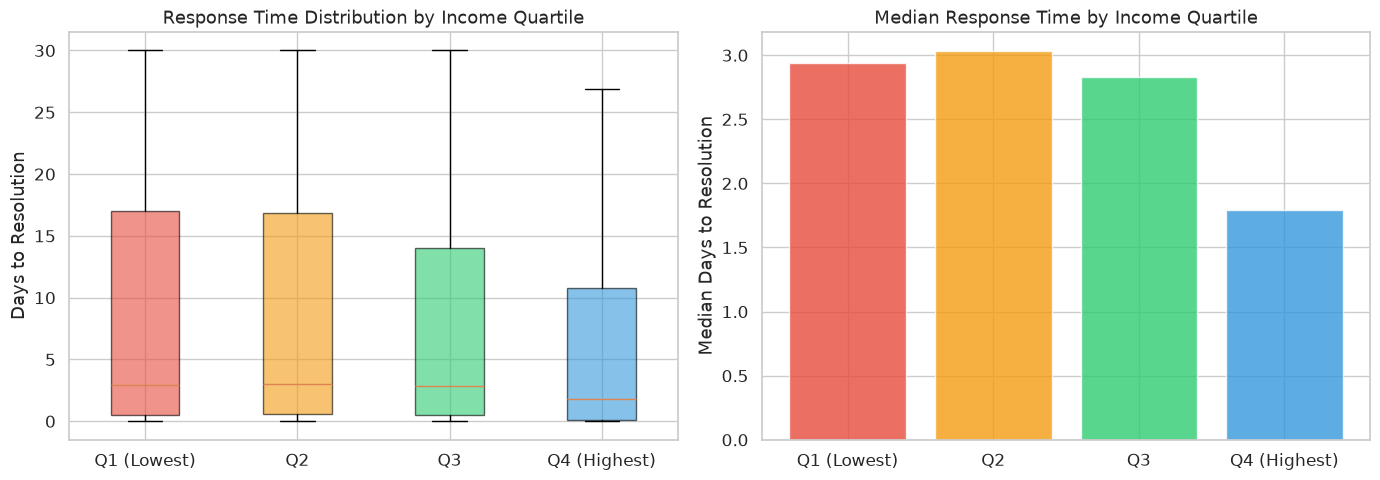

In [11]:
# Visualize response time by income quartile
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot (capped at 30 days for readability)
colors = ["#e74c3c", "#f39c12", "#2ecc71", "#3498db"]
data_by_q = [df_inc[df_inc["income_quartile"] == q]["response_days"].clip(upper=30) for q in q_labels]
bp = axes[0].boxplot(data_by_q, tick_labels=q_labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel("Days to Resolution")
axes[0].set_title("Response Time Distribution by Income Quartile")

# Bar chart of medians
axes[1].bar(q_labels, summary["median_days"], color=colors, edgecolor="white", alpha=0.8)
axes[1].set_ylabel("Median Days to Resolution")
axes[1].set_title("Median Response Time by Income Quartile")

plt.tight_layout()
plt.savefig(FIG_DIR / "response_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Statistical Testing

Visual differences could be due to chance. We use two statistical tests:

1. **Kruskal-Wallis H-test** — non-parametric test for whether response time distributions differ across income quartiles (appropriate because response times are heavily right-skewed)
2. **Mann-Whitney U test** — pairwise comparison between the lowest and highest income quartiles
3. **Bootstrap confidence intervals** — estimate the true difference in medians

In [12]:
# Kruskal-Wallis test across all 4 income quartiles
groups = [g["response_days"].values for _, g in df_inc.groupby("income_quartile")]
h_stat, p_kw = stats.kruskal(*groups)
print("Kruskal-Wallis H-test (all 4 quartiles)")
print(f"  H-statistic: {h_stat:.1f}")
print(f"  p-value: {p_kw:.2e}")
print(f"  Significant at α=0.05? {'Yes' if p_kw < 0.05 else 'No'}")

# Mann-Whitney U: Q1 (lowest income) vs Q4 (highest income)
q1 = df_inc[df_inc["income_quartile"] == "Q1 (Lowest)"]["response_days"]
q4 = df_inc[df_inc["income_quartile"] == "Q4 (Highest)"]["response_days"]
u_stat, p_mw = stats.mannwhitneyu(q1, q4, alternative="two-sided")
print(f"\nMann-Whitney U test: Q1 (Lowest) vs Q4 (Highest)")
print(f"  U-statistic: {u_stat:,.0f}")
print(f"  p-value: {p_mw:.2e}")
print(f"  Q1 median: {q1.median():.2f} days")
print(f"  Q4 median: {q4.median():.2f} days")
print(f"  Difference: {q1.median() - q4.median():.2f} days")

Kruskal-Wallis H-test (all 4 quartiles)
  H-statistic: 14073.2
  p-value: 0.00e+00
  Significant at α=0.05? Yes



Mann-Whitney U test: Q1 (Lowest) vs Q4 (Highest)
  U-statistic: 218,217,302,598
  p-value: 0.00e+00
  Q1 median: 2.94 days
  Q4 median: 1.79 days
  Difference: 1.16 days


Bootstrap 95% CI for median difference (Q1 - Q4):
  [0.94, 1.40] days
  Point estimate: 1.16 days


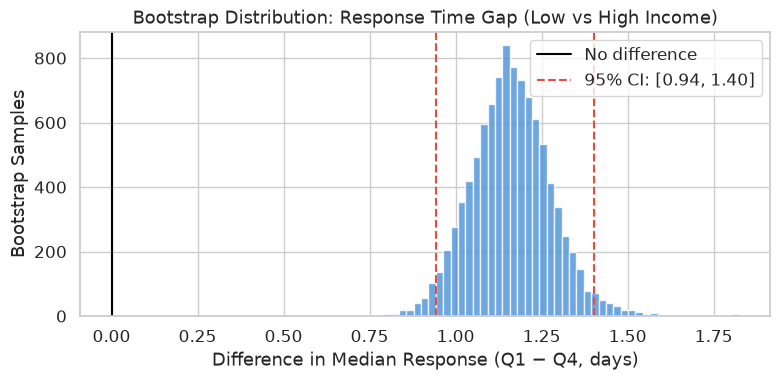

In [13]:
# Bootstrap confidence interval for the difference in medians (Q1 - Q4)
np.random.seed(42)
n_boot = 10000
boot_diffs = []

for _ in range(n_boot):
    q1_sample = q1.sample(n=min(5000, len(q1)), replace=True)
    q4_sample = q4.sample(n=min(5000, len(q4)), replace=True)
    boot_diffs.append(q1_sample.median() - q4_sample.median())

boot_diffs = np.array(boot_diffs)
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print(f"Bootstrap 95% CI for median difference (Q1 - Q4):")
print(f"  [{ci_lower:.2f}, {ci_upper:.2f}] days")
print(f"  Point estimate: {np.median(boot_diffs):.2f} days")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_diffs, bins=50, color="#4a90d9", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linestyle="-", linewidth=1.5, label="No difference")
ax.axvline(ci_lower, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")
ax.axvline(ci_upper, color="#e74c3c", linestyle="--", linewidth=1.5)
ax.set_xlabel("Difference in Median Response (Q1 − Q4, days)")
ax.set_ylabel("Bootstrap Samples")
ax.set_title("Bootstrap Distribution: Response Time Gap (Low vs High Income)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. What Do Different Neighborhoods Report?

Beyond response times, we can examine *what* different income groups report. Do lower-income neighborhoods report more infrastructure issues (potholes, streetlights) while higher-income areas report quality-of-life concerns (graffiti, trees)?

This tells a richer story about how different communities experience city services.

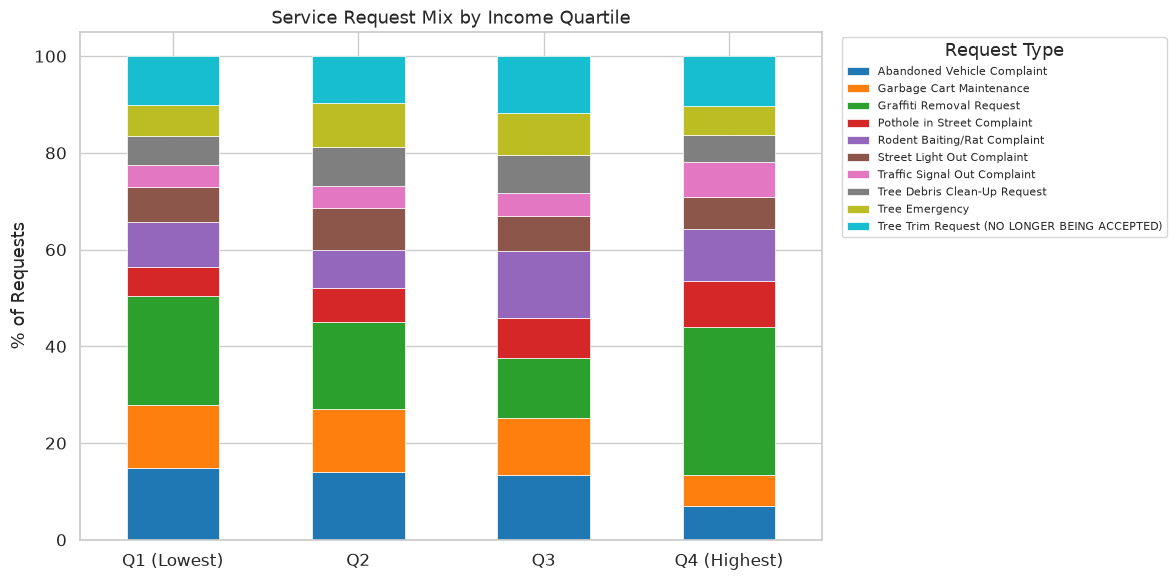

In [14]:
# Service type mix by income quartile
# Focus on top 10 types for readability
top10_types = df_inc["sr_type"].value_counts().head(10).index

type_by_q = (
    df_inc[df_inc["sr_type"].isin(top10_types)]
    .groupby(["income_quartile", "sr_type"])
    .size()
    .unstack(fill_value=0)
)

# Normalize to percentages within each quartile
type_pct = type_by_q.div(type_by_q.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
type_pct.plot.bar(stacked=True, ax=ax, colormap="tab10", edgecolor="white", linewidth=0.5)
ax.set_ylabel("% of Requests")
ax.set_xlabel("")
ax.set_title("Service Request Mix by Income Quartile")
ax.legend(title="Request Type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "request_mix_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

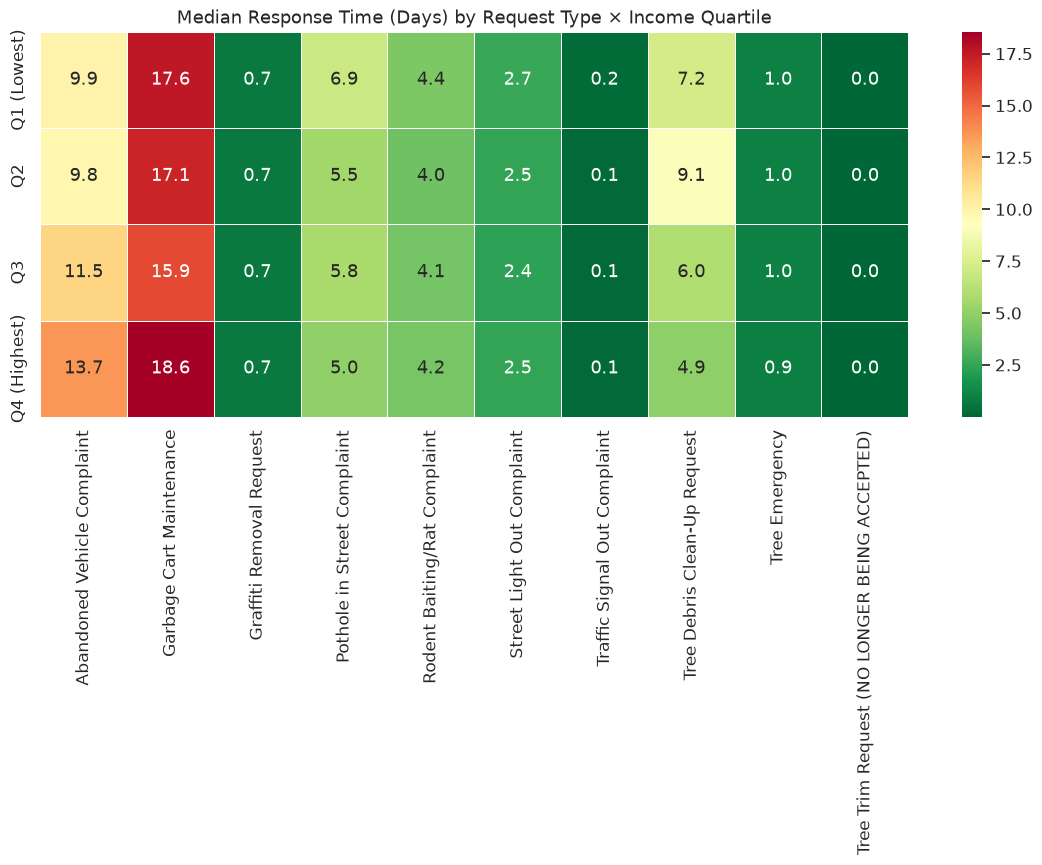

In [15]:
# Heatmap: median response time by request type × income quartile
pivot = (
    df_inc[df_inc["sr_type"].isin(top10_types)]
    .groupby(["income_quartile", "sr_type"])["response_days"]
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax, linewidths=0.5)
ax.set_title("Median Response Time (Days) by Request Type × Income Quartile")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_type_income.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Controlling for Request Type

A key confound: if lower-income neighborhoods report more complex issues (e.g., building violations vs. garbage carts), slower response times could reflect issue complexity rather than inequity.

We control for this by comparing response times **within the same request type** across income quartiles.

In [16]:
# Within-type comparison: for each of the top 10 types,
# test whether Q1 and Q4 have different response times
print(f"{'Request Type':<40} {'Q1 Median':>10} {'Q4 Median':>10} {'Diff':>8} {'p-value':>10}")
print("=" * 85)

within_type_results = []
for sr_type in top10_types:
    subset = df_inc[df_inc["sr_type"] == sr_type]
    q1_sub = subset[subset["income_quartile"] == "Q1 (Lowest)"]["response_days"]
    q4_sub = subset[subset["income_quartile"] == "Q4 (Highest)"]["response_days"]

    if len(q1_sub) < 30 or len(q4_sub) < 30:
        continue

    _, p = stats.mannwhitneyu(q1_sub, q4_sub, alternative="two-sided")
    diff = q1_sub.median() - q4_sub.median()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

    within_type_results.append({
        "sr_type": sr_type, "q1_median": q1_sub.median(), "q4_median": q4_sub.median(),
        "diff": diff, "p_value": p, "sig": sig,
    })
    print(f"{sr_type:<40} {q1_sub.median():>10.2f} {q4_sub.median():>10.2f} {diff:>+8.2f} {p:>10.2e} {sig}")

print(f"\n{'*'} p<0.05  {'**'} p<0.01  {'***'} p<0.001")

Request Type                              Q1 Median  Q4 Median     Diff    p-value
Graffiti Removal Request                       0.69       0.70    -0.01   2.42e-19 ***


Abandoned Vehicle Complaint                    9.93      13.66    -3.73  6.10e-107 ***
Garbage Cart Maintenance                      17.56      18.55    -0.99   6.64e-09 ***


Tree Trim Request (NO LONGER BEING ACCEPTED)       0.00       0.00    +0.00  2.74e-281 ***
Rodent Baiting/Rat Complaint                   4.40       4.22    +0.18   7.29e-01 


Pothole in Street Complaint                    6.90       4.95    +1.95  2.26e-118 ***
Street Light Out Complaint                     2.66       2.49    +0.17   1.68e-06 ***


Tree Emergency                                 0.98       0.88    +0.10   9.77e-23 ***
Tree Debris Clean-Up Request                   7.25       4.87    +2.37  2.32e-222 ***


Traffic Signal Out Complaint                   0.19       0.10    +0.09   4.14e-48 ***

* p<0.05  ** p<0.01  *** p<0.001


## 7. Geographic Visualization

Map median response time by community area to see spatial patterns. This reveals whether slow-response areas cluster geographically and correlate with income.

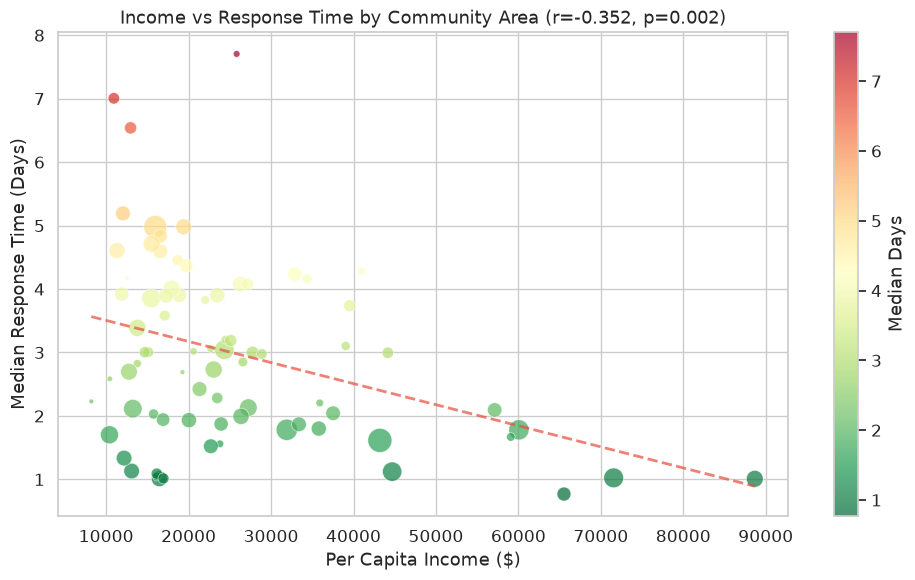

In [17]:
# Median response time and income by community area
ca_stats = df_inc.groupby("community_area").agg(
    median_response_days=("response_days", "median"),
    mean_response_days=("response_days", "mean"),
    request_count=("sr_number", "count"),
    per_capita_income=("per_capita_income", "first"),
).reset_index()

# Scatter plot: income vs response time by community area
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    ca_stats["per_capita_income"],
    ca_stats["median_response_days"],
    s=ca_stats["request_count"] / ca_stats["request_count"].max() * 300,
    c=ca_stats["median_response_days"],
    cmap="RdYlGn_r",
    alpha=0.7,
    edgecolors="white",
    linewidth=0.5,
)

# Trend line
z = np.polyfit(ca_stats["per_capita_income"].dropna(), ca_stats["median_response_days"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(ca_stats["per_capita_income"].min(), ca_stats["per_capita_income"].max(), 100)
ax.plot(x_line, p(x_line), "--", color="#e74c3c", linewidth=2, alpha=0.7)

# Correlation
r, p_val = stats.pearsonr(ca_stats["per_capita_income"].dropna(), ca_stats["median_response_days"].dropna())
ax.set_xlabel("Per Capita Income ($)")
ax.set_ylabel("Median Response Time (Days)")
ax.set_title(f"Income vs Response Time by Community Area (r={r:.3f}, p={p_val:.3f})")
plt.colorbar(scatter, label="Median Days")
plt.tight_layout()
plt.savefig(FIG_DIR / "income_vs_response_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Interactive choropleth map of response times
import folium
import json

# Load pre-downloaded Chicago community area boundaries
# Properties: community (name), area_numbe (CA number as string), area_num_1, shape_area, shape_len
with open(DATA_DIR / "community_areas.geojson") as f:
    ca_geo = json.load(f)
print(f"GeoJSON features: {len(ca_geo['features'])}")
print(f"Property keys: {list(ca_geo['features'][0]['properties'].keys())}")

# Enrich geojson with our stats
for feature in ca_geo["features"]:
    props = feature["properties"]
    try:
        ca_num = int(props.get("area_numbe", 0))
    except (ValueError, TypeError):
        ca_num = 0
    row = ca_stats[ca_stats["community_area"] == ca_num]
    if not row.empty:
        props["median_response_days"] = round(float(row["median_response_days"].iloc[0]), 1)
        props["per_capita_income"] = int(row["per_capita_income"].iloc[0])
        props["request_count"] = int(row["request_count"].iloc[0])
    else:
        props["median_response_days"] = None
        props["per_capita_income"] = None
        props["request_count"] = 0

# Build Folium map
m = folium.Map(location=[41.8781, -87.6298], zoom_start=10, tiles="OpenStreetMap")

folium.Choropleth(
    geo_data=ca_geo,
    data=ca_stats,
    columns=["community_area", "median_response_days"],
    key_on="feature.properties.area_numbe",
    fill_color="RdYlGn_r",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Median Response Time (Days)",
    nan_fill_color="white",
).add_to(m)

# Tooltips
folium.GeoJson(
    ca_geo,
    style_function=lambda x: {"fillOpacity": 0, "color": "gray", "weight": 0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=["community", "median_response_days", "per_capita_income", "request_count"],
        aliases=["Community Area", "Median Response (days)", "Per Capita Income ($)", "Total Requests"],
    ),
).add_to(m)

m.save(str(FIG_DIR / "chicago_311_map.html"))
print("Map saved to figures/chicago_311_map.html")
m

GeoJSON features: 77
Property keys: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len']


Map saved to figures/chicago_311_map.html


## 8. Temporal Patterns

Do equity gaps change over time? Are things getting better or worse?

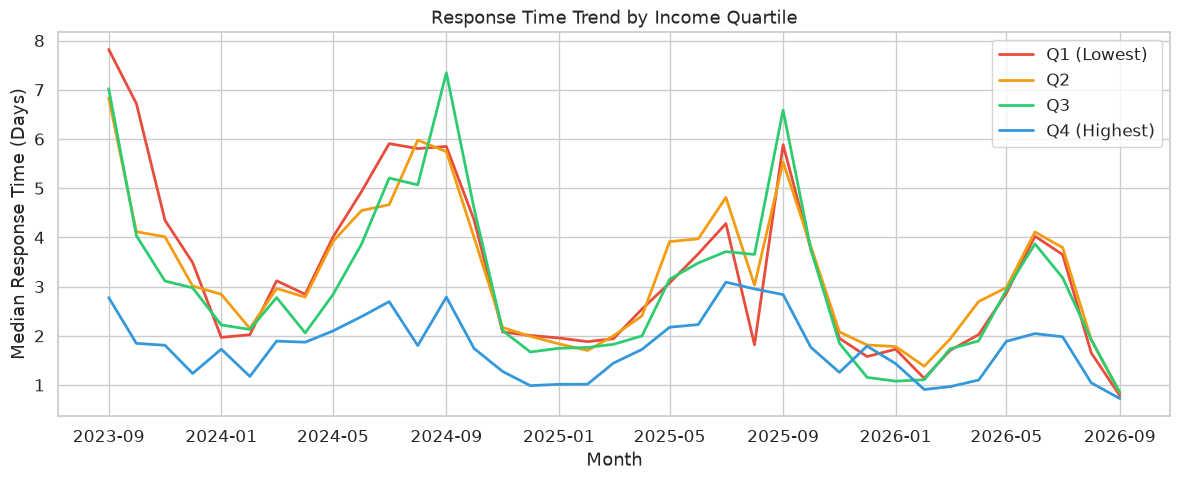

In [19]:
# Monthly median response time by income quartile
df_inc["month"] = df_inc["created_date"].dt.to_period("M")

monthly = (
    df_inc.groupby(["month", "income_quartile"])["response_days"]
    .median()
    .reset_index()
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for q, color in zip(q_labels, colors):
    subset = monthly[monthly["income_quartile"] == q]
    ax.plot(subset["month_dt"], subset["response_days"], label=q, color=color, linewidth=2)

ax.set_xlabel("Month")
ax.set_ylabel("Median Response Time (Days)")
ax.set_title("Response Time Trend by Income Quartile")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "trend_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. NLP: Topic Patterns in Service Requests

We use the service request type as a proxy for complaint "topics" and analyze how request vocabulary differs across income levels. We also look at the `origin` field (phone, internet, app) — do lower-income areas rely more on phone calls while wealthier areas use the web?

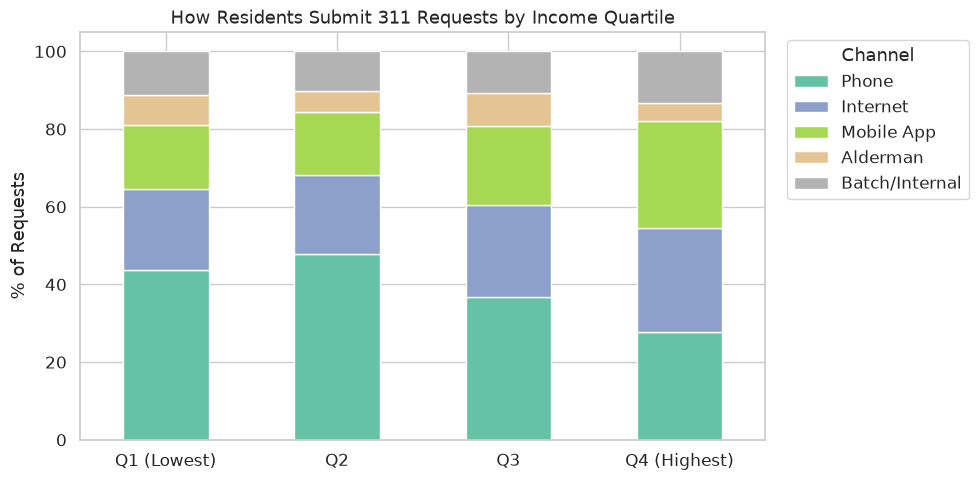


Submission channel breakdown (%):
origin_group     Phone  Internet  Mobile App  Alderman  Batch/Internal
income_quartile                                                       
Q1 (Lowest)      43.70     20.80       16.50      7.90           11.20
Q2               47.90     20.30       16.10      5.50           10.20
Q3               36.70     23.70       20.50      8.40           10.70
Q4 (Highest)     27.70     26.70       27.50      4.70           13.40


In [20]:
# Digital divide: how do people submit requests?
# Group 34 origin values into clean categories
origin_map = {
    "Phone Call": "Phone", "Phone": "Phone",
    "Internet": "Internet",
    "Mobile Device": "Mobile App", "Salesforce Mobile App": "Mobile App",
    "Mass Entry": "Batch/Internal",
    "Alderman's Office": "Alderman",
    "Generated In House": "Batch/Internal", "DWM": "Batch/Internal",
    "City Department": "Batch/Internal", "CSCC": "Batch/Internal",
}
df_inc["origin_group"] = df_inc["origin"].map(origin_map).fillna("Other")

origin_by_q = (
    df_inc.groupby(["income_quartile", "origin_group"], observed=True)
    .size()
    .unstack(fill_value=0)
)
# Keep only the main channels
main_channels = ["Phone", "Internet", "Mobile App", "Alderman", "Batch/Internal"]
origin_by_q = origin_by_q[[c for c in main_channels if c in origin_by_q.columns]]
origin_pct = origin_by_q.div(origin_by_q.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
origin_pct.plot.bar(stacked=True, ax=ax, colormap="Set2", edgecolor="white")
ax.set_ylabel("% of Requests")
ax.set_xlabel("")
ax.set_title("How Residents Submit 311 Requests by Income Quartile")
ax.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "origin_by_income.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSubmission channel breakdown (%):")
print(origin_pct.round(1).to_string())

In [21]:
# TF-IDF on service request types to find distinguishing request categories per quartile
from sklearn.feature_extraction.text import TfidfVectorizer

# Build a "document" per quartile: concatenate all request type names
quartile_docs = (
    df_inc.groupby("income_quartile")["sr_type"]
    .apply(lambda x: " ".join(x.str.lower().str.replace("[^a-z ]", "", regex=True)))
)

tfidf = TfidfVectorizer(max_features=50, ngram_range=(1, 2), stop_words="english")
tfidf_matrix = tfidf.fit_transform(quartile_docs)
feature_names = tfidf.get_feature_names_out()

# Top distinguishing terms per quartile
print("Most distinctive request terms by income quartile:\n")
for i, q in enumerate(quartile_docs.index):
    scores = tfidf_matrix[i].toarray().flatten()
    top_idx = scores.argsort()[-8:][::-1]
    terms = [(feature_names[j], scores[j]) for j in top_idx]
    print(f"  {q}:")
    for term, score in terms:
        print(f"    {term:<30} {score:.3f}")
    print()

Most distinctive request terms by income quartile:

  Q1 (Lowest):
    complaint                      0.536
    request                        0.488
    removal                        0.223
    tree                           0.206
    removal request                0.204
    graffiti                       0.174
    graffiti removal               0.174
    cart                           0.141

  Q2:
    complaint                      0.546
    request                        0.490
    tree                           0.237
    removal                        0.193
    removal request                0.170
    street                         0.158
    cart                           0.138
    graffiti                       0.137

  Q3:
    complaint                      0.555
    request                        0.459
    tree                           0.264
    street                         0.160
    removal                        0.147
    cart                           0.137
    vehicle      

## 10. Conclusions

### Summary of Findings

*(To be filled after running the analysis — the narrative will depend on what the data shows)*

**Methodology:**
- Analyzed 3 years of completed 311 service requests from the Chicago Data Portal
- Joined with Census ACS socioeconomic indicators by community area
- Divided 77 community areas into income quartiles
- Compared response times using non-parametric tests (Kruskal-Wallis, Mann-Whitney U)
- Controlled for request type to isolate the income effect
- Used bootstrap confidence intervals to estimate effect size
- Examined geographic patterns and submission channel disparities

**Limitations:**
- Response time measures time from creation to closure, which may not capture actual service delivery
- Community area income is a proxy — individual-level income data is not available
- Some request types may have standardized response workflows that mask real differences
- Duplicate requests (filtered) could bias results if duplication rates vary by area
- Socioeconomic data is a point-in-time snapshot; neighborhood income may have shifted

**Tools:** Python, Pandas, Scikit-learn, SciPy, Plotly, Folium, Socrata API

---

*Analysis by [Peter Keel](https://keelp2.github.io) · Data from [Chicago Data Portal](https://data.cityofchicago.org/) and U.S. Census ACS*

# Chicago 311: Do Wealthier Neighborhoods Get Faster City Services?\n\n**An equity analysis of 3 years of Chicago 311 service requests**\n\nChicago receives millions of 311 service requests each year — potholes, streetlights, rodent complaints, graffiti, and more. This analysis investigates whether response times and service quality vary systematically by neighborhood income level.\n\n**Research Question:** Do wealthier Chicago neighborhoods receive faster 311 service responses than lower-income neighborhoods?\n\n**Approach:**\n1. Pull 3 years of completed 311 requests with location data (14M+ records)\n2. Join with Census socioeconomic data by community area\n3. Compare response times across income quartiles\n4. Use NLP to understand what different neighborhoods report\n5. Test significance with statistical methods\n\n---